# Import

In [ ]:
# CUDA_VISIBLE_DEVICES=0,1,2,3 vllm serve /data/home/zhangchen/models/Qwen3.5/Qwen3.5-122B-A10B \
#     --tensor-parallel-size 4 --port 7999 --host 0.0.0.0 --gpu-memory-utilization 0.90  --max-num-seqs 40 --max-model-len 65536  \
#     --served-model-name Qwen3.5-122B-A10B\
#     --reasoning-parser qwen3 \
#     --enable-auto-tool-choice --tool-call-parser qwen3_coder 

In [2]:
import asyncio
import os
import base64
import json
from typing import Literal, Tuple, Annotated, Optional, Union, List, Any, Dict, Sequence

from pydantic import BaseModel, Field, ConfigDict

import math
import base64
import copy
from io import BytesIO
from PIL import ImageColor, Image, ImageDraw, ImageFont

from transformers import Qwen3VLMoeForConditionalGeneration, Qwen3VLForConditionalGeneration, AutoProcessor

from agentscope.agent import ReActAgent, UserAgent
from agentscope.formatter import OpenAIChatFormatter, OpenAIMultiAgentFormatter
from agentscope.memory import InMemoryMemory
from agentscope.model import OpenAIChatModel
from agentscope.agent import ReActAgent
from agentscope.tool import ToolResponse, Toolkit, execute_python_code, write_text_file
from agentscope.message import (
    Msg,
    Base64Source,
    TextBlock,
    URLSource,
    ThinkingBlock,
    ImageBlock,
    ToolUseBlock,
    ToolResultBlock,
    VideoBlock,
    AudioBlock
)
import requests
import openai
import openslide
import uuid
import shortuuid
import numpy as np
import cv2
import matplotlib.pyplot as plt
# from qwen_vl_utils import process_vision_info, extract_vision_info

/data/home/zhangchen/miniconda3/envs/vllm18/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Base Crop Tool

In [3]:
MAX_RATIO = 200
SPATIAL_MERGE_SIZE = 2
IMAGE_MIN_TOKEN_NUM = 4
IMAGE_MAX_TOKEN_NUM = 16384
VIDEO_MIN_TOKEN_NUM = 128
VIDEO_MAX_TOKEN_NUM = 768

FPS = 2.0
FRAME_FACTOR = 2
FPS_MIN_FRAMES = 4
FPS_MAX_FRAMES = 768
MAX_NUM_WORKERS_FETCH_VIDEO = 8

def round_by_factor(number: int, factor: int) -> int:
    """Returns the closest integer to 'number' that is divisible by 'factor'."""
    return round(number / factor) * factor


def ceil_by_factor(number: int, factor: int) -> int:
    """Returns the smallest integer greater than or equal to 'number' that is divisible by 'factor'."""
    return math.ceil(number / factor) * factor


def floor_by_factor(number: int, factor: int) -> int:
    """Returns the largest integer less than or equal to 'number' that is divisible by 'factor'."""
    return math.floor(number / factor) * factor


def to_rgb(pil_image: Image.Image) -> Image.Image:
      if pil_image.mode == 'RGBA':
          white_background = Image.new("RGB", pil_image.size, (255, 255, 255))
          white_background.paste(pil_image, mask=pil_image.split()[3])  # Use alpha channel as mask
          return white_background
      else:
          return pil_image.convert("RGB")
      
def smart_resize(height: int, width: int, factor: int = 32) -> Tuple[int, int]:
    """
    Rescales the image so that the following conditions are met:

    1. Both dimensions (height and width) are divisible by 'factor'.
    2. The total number of pixels is within the range ['min_pixels', 'max_pixels'].
    3. The aspect ratio of the image is maintained as closely as possible.
    """
    max_pixels =  (IMAGE_MAX_TOKEN_NUM * factor ** 2)
    min_pixels =  (IMAGE_MIN_TOKEN_NUM * factor ** 2)
    assert max_pixels >= min_pixels, "The max_pixels of image must be greater than or equal to min_pixels."
    if max(height, width) / min(height, width) > MAX_RATIO:
        raise ValueError(
            f"absolute aspect ratio must be smaller than {MAX_RATIO}, got {max(height, width) / min(height, width)}"
        )
    h_bar = max(factor, round_by_factor(height, factor))
    w_bar = max(factor, round_by_factor(width, factor))
    return h_bar, w_bar

def validate_MinMax_pixels(bbox, w_bar, h_bar, image_idx, origin_mag, target_mag, max_pixels, min_pixels):
    
    rel_x1, rel_y1, rel_x2, rel_y2 = bbox

    pixels = w_bar * h_bar
    coord_note = (
        "Qwen3-VL bbox coords are relative on a 0-1000 scale "
        "Convert to pixels: abs_px = rel/1000 * (img_w,img_h)."
    )    
    if pixels > max_pixels:
        raise ValueError(
            "WSI_PATCH_TOO_LARGE: "
            f"image_idx={image_idx}; "
            f"origin_wsi_magnification=x{origin_mag}; "
            f"target_wsi_magnification=x{target_mag}; "
            f"bbox_2d=[{rel_x1},{rel_y1},{rel_x2},{rel_y2}]; "
            f"corresponding_image_wh={w_bar}x{h_bar}; "
            f"patch_pixels={pixels} > max_pixels={max_pixels}; "
            f"coord_note={coord_note} "
            "Action: shrink bbox (reduce area) and retry with same image_idx & target_wsi_magnification."
        )

    elif pixels < min_pixels:
        raise ValueError(
            "WSI_PATCH_TOO_SMALL: "
            f"image_idx={image_idx}; "
            f"origin_wsi_magnification=x{origin_mag}; "
            f"target_wsi_magnification=x{target_mag}; "
            f"bbox_2d=[{rel_x1},{rel_y1},{rel_x2},{rel_y2}]; "
            f"corresponding_image_wh={w_bar}x{h_bar}; "
            f"patch_pixels={pixels} < min_pixels={min_pixels}; "
            f"coord_note={coord_note} "
            "Action: expand_bbox (increase area) and retry with same image_idx & target_wsi_magnification."
        )
    
def validate_MinMax_pixels_test(bbox, w_bar, h_bar, max_pixels, min_pixels):
    
    rel_x1, rel_y1, rel_x2, rel_y2 = bbox

    pixels = w_bar * h_bar
    coord_note = (
        "Qwen3-VL bbox coords are relative on a 0-1000 scale "
        "Convert to pixels: abs_px = rel/1000 * (img_w,img_h)."
    )    
    if pixels > max_pixels:
        raise ValueError(
            "BBOX_PATCH_TOO_LARGE: "
            f"bbox_2d=[{rel_x1},{rel_y1},{rel_x2},{rel_y2}]; "
            f"corresponding_image_wh={w_bar}x{h_bar}; "
            f"patch_pixels={pixels} > max_pixels={max_pixels}; "
            f"coord_note={coord_note} "
            "Action: shrink bbox (reduce area)"
        )

    elif pixels < min_pixels:
        raise ValueError(
            "BBOX_PATCH_TOO_SMALL: "
            f"bbox_2d=[{rel_x1},{rel_y1},{rel_x2},{rel_y2}]; "
            f"corresponding_image_wh={w_bar}x{h_bar}; "
            f"patch_pixels={pixels} < min_pixels={min_pixels}; "
            f"coord_note={coord_note} "
            "Action: expand_bbox (increase area)"
        )
    
def maybe_resize_bbox(left, top, right, bottom, img_width, img_height, factor=32):
    """Resize bbox to ensure it's valid"""
    left = max(0, left)
    top = max(0, top)
    right = min(img_width, right)
    bottom = min(img_height, bottom)

    height = bottom - top
    width = right - left
    if height < factor or width < factor:
        center_x = (left + right) / 2.0
        center_y = (top + bottom) / 2.0
        ratio = factor / min(height, width)
        new_half_height = math.ceil(height * ratio * 0.5)
        new_half_width = math.ceil(width * ratio * 0.5)
        new_left = math.floor(center_x - new_half_width)
        new_right = math.ceil(center_x + new_half_width)
        new_top = math.floor(center_y - new_half_height)
        new_bottom = math.ceil(center_y + new_half_height)

        # Ensure the resized bbox is within image bounds
        new_left = max(0, new_left)
        new_top = max(0, new_top)
        new_right = min(img_width, new_right)
        new_bottom = min(img_height, new_bottom)

        new_height = new_bottom - new_top
        new_width = new_right - new_left

        if new_height >= factor and new_width >= factor:
            return [new_left, new_top, new_right, new_bottom]
        else:
            raise ValueError(f"new_height: {new_height} or new_width: {new_width} < 32, need to increase the bbox area ")
    return [left, top, right, bottom]

obersvaton_list = []
work_dir = "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB"
action_idx = 1
def zoom_in_image(
    bbox_2d: Annotated[list[float], Field(min_length=4, max_length=4)],
    label: str,
    observation_index: Annotated[int, Field(ge=0)],
) -> ToolResponse:

    """Zoom in on a specific region of an image by cropping it based on a bounding box (bbox) and an optional object label.

    Args:
        bbox_2d (`list[float]`):
            The bounding box of the region to zoom in, as [x1, y1, x2, y2], where (x1, y1) is the top-left corner (x1 is left and y1 is top) and (x2, y2) is the bottom-right corner (x2 is right and y2 is bottom). The bounding box uses the relative coordinated with range 0-1000.
        label (`str`):
            The name or label of the object in the specified bounding box.
        observation_index (`int`):
            The index of the image to zoom-in(starting from 0). The index of the image to crop.

    Returns:
        `ToolResponse`:
            The tool response containing the result of the writing operation.
    """
    global action_idx
    try: 
        img_file_path = obersvaton_list[observation_index]

        if not os.path.exists(img_file_path):
            raise ValueError(f'img_file_path: {img_file_path} is not exist')

        original_image = to_rgb(Image.open(img_file_path))

        img_width, img_height  = original_image.size

        rel_x1, rel_y1, rel_x2, rel_y2 = bbox_2d

        abs_x1 = math.floor(rel_x1 / 1000. * img_width)
        abs_y1 = math.floor(rel_y1 / 1000. * img_height)
        abs_x2 = math.ceil(rel_x2 / 1000. * img_width)
        abs_y2 = math.ceil(rel_y2 / 1000. * img_height)

        # maybe we can directly crop * 32 insteaded of resize ?

        validated_bbox = maybe_resize_bbox(abs_x1, abs_y1, abs_x2, abs_y2, img_width, img_height)


        left, top, right, bottom = validated_bbox


        # Crop the image

        cropped_image = original_image.crop((left, top, right, bottom))

        new_w, new_h = smart_resize((right - left), (bottom - top), factor=32)

        validate_MinMax_pixels_test(bbox_2d, new_w, new_h, max_pixels= 16384 * 32 * 32, min_pixels= 4 * 32 * 32)    
        
        cropped_image = cropped_image.resize((new_w, new_h), resample=Image.BICUBIC)

        # save crop image

        output_path = os.path.abspath(os.path.join(work_dir, f'observation_{action_idx}_{shortuuid.uuid()}.png'))
        cropped_image.save(output_path)

        new_img_idx = len(obersvaton_list)
        obersvaton_list.append(output_path)
        action_idx += 1
        return ToolResponse(
        content=[
            TextBlock(
                type="text",
                text=(
                    "zoom_in_image succeeded.\n"
                    "Generated a zoomed-in ROI view (image) from the selected bounding box.\n"
                    f"- returned observation_index: {new_img_idx}\n"
                    f"- source observation_index: {observation_index}\n"
                    f"- label: {label}\n"
                    f"To reference this ROI view in later tool calls, use observation_index={new_img_idx}."
                ),
            ),
            ImageBlock(
                type="image",
                source=URLSource(
                    type="url",
                    url=output_path
                )
            )
        ],
        metadata={
            "success": True,
            "observation_index": new_img_idx,
            "source_observation_index" : observation_index
            }
        )
    
    except Exception as e:
        obs = f'Tool Execution Error {str(e)}'
        return ToolResponse(
        content=[
            TextBlock(
                type="text",
                text=f"Failure to execute zoom_in_image, error: {obs}.",
            )
        ],
        metadata={"success": False}
        )

In [4]:
import openslide

In [5]:
def get_roi_at_mpp_optimized(
    slide: openslide.OpenSlide,
    source_roi: tuple[int, int, int, int],
    source_mpp: float,
    source_level0_x: int,
    source_level0_y: int,
    target_mpp: float,
    level0_mpp: float,
    min_pixels: int = 32
) -> tuple[Image.Image, tuple[int, int, int, int]]:
    """
    严格禁止升采样。如果目标MPP高于原生分辨率,则输出原生最高分辨率的图像。
    返回图像、其在Level 0的ROI坐标,以及图像的最终有效MPP。
    """
    # 1. 获取基础MPP和所有层级的MPP
    native_mpp = level0_mpp
    width, height = slide.dimensions

    # 2. 将源ROI换算到Level 0坐标 (所有计算的基准)
    scale_factor_to_level0 = source_mpp / native_mpp
    src_x, src_y, src_w, src_h = source_roi
    src_x, src_y, src_w, src_h = source_roi
    if src_x < 0 or src_y < 0 or src_w <= 0 or src_h <= 0 or source_level0_x <0 or source_level0_y < 0 :
        raise ValueError(
            f"source_level0_x: {source_level0_x}, source_level0_y: {source_level0_y}, src_x: {src_x}, src_y: {src_y}, src_w: {src_w} and src_h: {src_h} must be larger than 0"
        )
    level0_x = math.floor(src_x * scale_factor_to_level0) + source_level0_x
    level0_y = math.floor(src_y * scale_factor_to_level0) + source_level0_y
    level0_w = math.floor(src_w * scale_factor_to_level0)
    level0_h = math.floor(src_h * scale_factor_to_level0)
    output_level0_roi = (level0_x, level0_y, level0_w, level0_h)

    if level0_x + level0_w> width or level0_y + level0_h > height:
        raise ValueError(
            f"level0_x: {level0_x} + level0_w: {level0_w} = {level0_x + level0_w} be smaller than width: {width}, and level0_y: {level0_y} + level0_h: {level0_h} = {level0_y + level0_h} be smaller than height: {height}"
        )


    # 3. 【核心限制逻辑】根据目标MPP决定最终尺寸和读取层级
    if target_mpp < native_mpp:
        # --- 情况A: 请求的分辨率过高，执行限制 ---
        # logging.warning(f"目标MPP {target_mpp:.4f} 高于最大分辨率 {native_mpp:.4f}。将输出最大分辨率图像。")
        print(f"目标MPP {target_mpp:.4f} 高于最大分辨率 {native_mpp:.4f}。将输出最大分辨率图像 {native_mpp:.4f}。")
        
        # 目标尺寸被限制在Level 0的尺寸
        target_w = max(min_pixels, level0_w)
        target_h = max(min_pixels, level0_h)
        # 最终的有效MPP是原生MPP
        effective_mpp = native_mpp
        # 必须从Level 0读取
        optimal_level = 0
        
        # 确保尺寸至少为1
        optimal_level_w = max(min_pixels, level0_w)
        optimal_level_h = max(min_pixels, level0_h)

    else:
        # --- 情况B: 请求的分辨率有效，执行优化逻辑 ---
        effective_mpp = target_mpp
        level_mpps = [native_mpp * ds for ds in slide.level_downsamples]
        valid_levels = [i for i, mpp in enumerate(level_mpps) if mpp <= target_mpp]
        optimal_level = valid_levels[-1] # 选择最接近的层级
        
        # logging.info(f"目标MPP: {target_mpp:.2f} -> 智能选择从 Level {optimal_level} (MPP: {level_mpps[optimal_level]:.2f}) 读取数据。")
        print(f"目标MPP: {target_mpp:.2f} -> 智能选择从 Level {optimal_level} (MPP: {level_mpps[optimal_level]:.2f}) 读取数据。")

        optimal_level_downsample = slide.level_downsamples[optimal_level]
        optimal_level_w = max(min_pixels, math.floor(level0_w / optimal_level_downsample))
        optimal_level_h = max(min_pixels, math.floor(level0_h / optimal_level_downsample))
        
        scale_factor_to_target = native_mpp / target_mpp
        target_w = max(min_pixels, math.floor(level0_w * scale_factor_to_target))
        target_h = max(min_pixels, math.floor(level0_h * scale_factor_to_target))

    print(f"level0_w: {level0_w}, level0_h:{level0_h} -> optimal_level_w: {optimal_level_w}, optimal_level_h: {optimal_level_h} -> target_w: {target_w},  target_h: {target_h} 。")
    intermediate_image = slide.read_region(
        (level0_x, level0_y),
        optimal_level,
        (optimal_level_w, optimal_level_h)
    )
    # 4. 进行最后的微调缩放（如果需要）
    if intermediate_image.size != (target_w, target_h):
        target_image = intermediate_image.resize((target_w, target_h), Image.Resampling.LANCZOS)
    else:
        target_image = intermediate_image
    
    return target_image.convert("RGB"), output_level0_roi, effective_mpp, level0_w, level0_h, optimal_level_w, optimal_level_h, target_w, target_h

# Base Silde Crop

In [6]:
reg_path = '/mnt/remote_226_sda/datasets/Reg2025/REG_train/PIT_01_01591_01.tiff'
TCGA_path = '/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs/TCGA-AN-A0G0-01Z-00-DX1.BE0BB5DF-DEDA-48D8-B5D8-2735C767F28F.svs'
reg_sample = openslide.OpenSlide(reg_path)
tcga_sample = openslide.OpenSlide(TCGA_path)

In [7]:
w, h = reg_sample.dimensions

In [10]:
image_test = reg_sample.read_region((0, 0), 0, (w, h)).resize((1024, 1024) ,Image.Resampling.LANCZOS)

In [11]:
image_test.size

(1024, 1024)

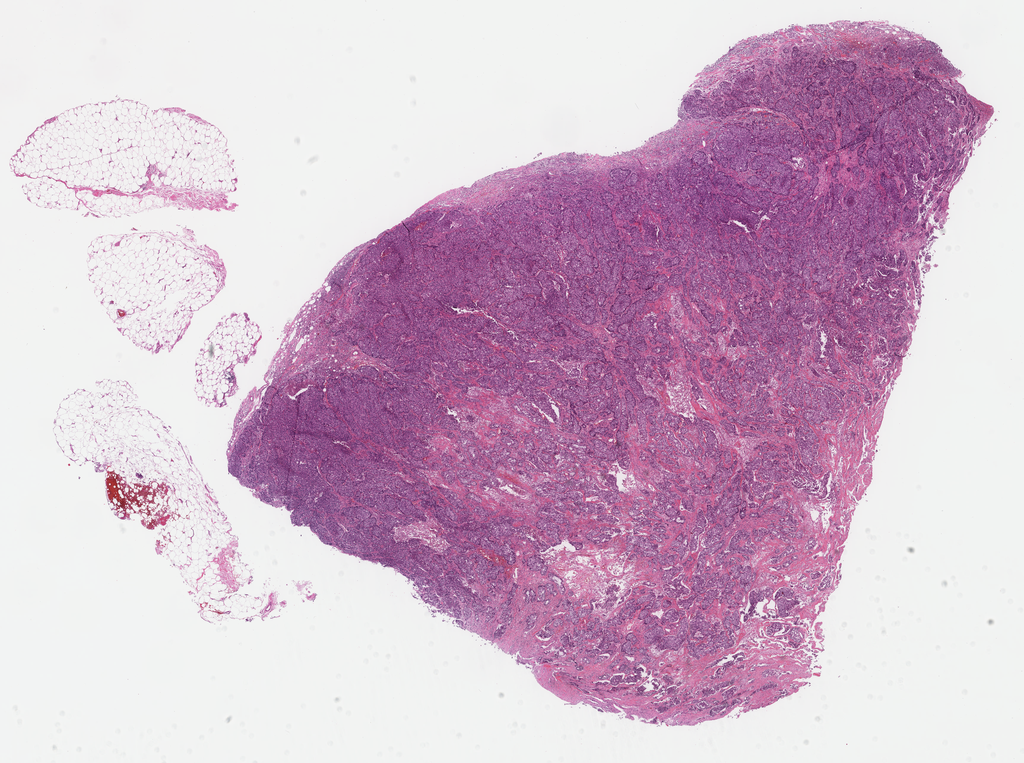

In [7]:
tcga_sample.get_thumbnail((1024, 1024))

In [8]:
tcga_sample.dimensions

(55215, 41144)

In [9]:
reg_sample.dimensions       

(23926, 26047)

In [8]:
def get_roi(
    slide: openslide.OpenSlide,
    x1:int,
    y1:int,
    x2:int,
    y2:int,
    bbox_2d: Annotated[list[float], Field(min_length=4, max_length=4)],
    level0_mpp: float,
    target_mpp: float,
    min_pixels:int = 32
) -> None:
    rel_x1, rel_y1, rel_x2, rel_y2 = bbox_2d
    w = x2 - x1
    h = y2 - y1

    # 将源ROI换算到Level 0坐标 (所有计算的基准)
    abs_x1 = math.floor(rel_x1 / 1000. * w) + x1
    abs_y1 = math.floor(rel_y1 / 1000. * h) + y1
    abs_x2 = math.ceil(rel_x2 / 1000. * w)  + x1
    abs_y2 = math.ceil(rel_y2 / 1000. * h)  + y1

    level0_w = abs_x2 - abs_x1
    level0_h = abs_y2 - abs_y1

    # 【核心限制逻辑】根据目标MPP决定最终尺寸和读取层级
    if target_mpp < level0_mpp:
        # --- 情况A: 请求的分辨率过高，执行限制 ---
        # logging.warning(f"目标MPP {target_mpp:.4f} 高于最大分辨率 {level0_mpp:.4f}。将输出最大分辨率图像。")
        print(f"目标MPP {target_mpp:.4f} 高于最大分辨率 {level0_mpp:.4f}。将输出最大分辨率图像 {level0_mpp:.4f}。")

        # 目标尺寸被限制在Level 0的尺寸
        target_w = max(min_pixels, level0_w)
        target_h = max(min_pixels, level0_h)
        # 最终的有效MPP是原生MPP
        effective_mpp = level0_mpp
        # 必须从Level 0读取
        optimal_level = 0
        
        # 确保尺寸至少为1
        optimal_level_w = max(min_pixels, level0_w)
        optimal_level_h = max(min_pixels, level0_h)
    
    else:
        # --- 情况B: 请求的分辨率有效，执行优化逻辑 ---
        effective_mpp = target_mpp
        level_mpps = [level0_mpp * ds for ds in slide.level_downsamples]
        valid_levels = [i for i, mpp in enumerate(level_mpps) if mpp <= target_mpp]
        optimal_level = valid_levels[-1] # 选择最接近的层级
        
        # logging.info(f"目标MPP: {target_mpp:.2f} -> 智能选择从 Level {optimal_level} (MPP: {level_mpps[optimal_level]:.2f}) 读取数据。")
        print(f"目标MPP: {target_mpp:.2f} -> 智能选择从 Level {optimal_level} (MPP: {level_mpps[optimal_level]:.2f}) 读取数据。")

        optimal_level_downsample = slide.level_downsamples[optimal_level]
        optimal_level_w = max(min_pixels, math.floor(level0_w / optimal_level_downsample))
        optimal_level_h = max(min_pixels, math.floor(level0_h / optimal_level_downsample))
        
        scale_factor_to_target = level0_mpp / target_mpp
        target_w = max(min_pixels, math.floor(level0_w * scale_factor_to_target))
        target_h = max(min_pixels, math.floor(level0_h * scale_factor_to_target))

    print(f"level0_w: {level0_w}, level0_h:{level0_h} -> optimal_level_w: {optimal_level_w}, optimal_level_h: {optimal_level_h} -> target_w: {target_w},  target_h: {target_h} 。")
    intermediate_image = slide.read_region(
            (abs_x1, abs_y1),
            optimal_level,
            (optimal_level_w, optimal_level_h)
    )

    if intermediate_image.size != (target_w, target_h):
            target_image = intermediate_image.resize((target_w, target_h), Image.Resampling.LANCZOS)
    else:
            target_image = intermediate_image

In [9]:
slide: openslide.OpenSlide = None
slide_meta_list: List[Dict] = [
    {
        'source_level0_x1' : 0,
        'source_level0_y1' : 0,
        'source_level0_x2' : 0,
        'source_level0_y2' : 0,
        'level0_mpp' : 0.2,
        'source_mpp' : 0.5
    }
]
obersvaton_list = [

]
def zoom_in_slide_image(
    bbox_2d: Annotated[list[float], Field(min_length=4, max_length=4)],
    target_mpp: float,
    label: str,
    observation_index: Annotated[int, Field(ge=0)],
) -> ToolResponse:

    """Zoom in on a specific region of an image by cropping it based on a bounding box (bbox) and an optional object label.

    Args:
        bbox_2d (`list[float]`):
            The bounding box of the region to zoom in, as [x1, y1, x2, y2], where (x1, y1) is the top-left corner (x1 is left and y1 is top) and (x2, y2) is the bottom-right corner (x2 is right and y2 is bottom). The bounding box uses the relative coordinated with range 0-1000.
        label (`str`):
            The name or label of the object in the specified bounding box.
        observation_index (`int`):
            The index of the image to zoom-in(starting from 0). The index of the image to crop.

    Returns:
        `ToolResponse`:
            The tool response containing the result of the writing operation.
    """
    global action_idx
    try: 
        img_file_path = obersvaton_list[observation_index]

        if not os.path.exists(img_file_path):
            raise ValueError(f'img_file_path: {img_file_path} is not exist')

        original_image = to_rgb(Image.open(img_file_path))

        img_width, img_height  = original_image.size

        rel_x1, rel_y1, rel_x2, rel_y2 = bbox_2d

        abs_x1 = math.floor(rel_x1 / 1000. * img_width)
        abs_y1 = math.floor(rel_y1 / 1000. * img_height)
        abs_x2 = math.ceil(rel_x2 / 1000. * img_width)
        abs_y2 = math.ceil(rel_y2 / 1000. * img_height)

        # maybe we can directly crop * 32 insteaded of resize ?

        validated_bbox = maybe_resize_bbox(abs_x1, abs_y1, abs_x2, abs_y2, img_width, img_height)


        left, top, right, bottom = validated_bbox

        
        # Crop the image

        cropped_image = original_image.crop((left, top, right, bottom))

        new_w, new_h = smart_resize((right - left), (bottom - top), factor=32)

        validate_MinMax_pixels_test(bbox_2d, new_w, new_h, max_pixels= 16384 * 32 * 32, min_pixels= 4 * 32 * 32)    
        
        cropped_image = cropped_image.resize((new_w, new_h), resample=Image.BICUBIC)

        # save crop image

        output_path = os.path.abspath(os.path.join(work_dir, f'observation_{action_idx}_{shortuuid.uuid()}.png'))
        cropped_image.save(output_path)

        new_img_idx = len(obersvaton_list)
        obersvaton_list.append(output_path)
        action_idx += 1
        return ToolResponse(
        content=[
            TextBlock(
                type="text",
                text=(
                    "zoom_in_image succeeded.\n"
                    "Generated a zoomed-in ROI view (image) from the selected bounding box.\n"
                    f"- returned observation_index: {new_img_idx}\n"
                    f"- source observation_index: {observation_index}\n"
                    f"- label: {label}\n"
                    f"To reference this ROI view in later tool calls, use observation_index={new_img_idx}."
                ),
            ),
            ImageBlock(
                type="image",
                source=URLSource(
                    type="url",
                    url=output_path
                )
            )
        ],
        metadata={
            "success": True,
            "observation_index": new_img_idx,
            "source_observation_index" : observation_index
            }
        )
    
    except Exception as e:
        obs = f'Tool Execution Error {str(e)}'
        return ToolResponse(
        content=[
            TextBlock(
                type="text",
                text=f"Failure to execute zoom_in_image, error: {obs}.",
            )
        ],
        metadata={"success": False}
        )

# Multimodel print

In [10]:
_stream_prefix = {}

def _print_text_block(
    _stream_prefix,
    msg_id: str,
    name_prefix: str,
    text_content: str,
    thinking_and_text_to_print: list[str],
) -> None:
    """Print the text block and thinking block content.

    Args:
        msg_id (`str`):
            The unique identifier of the message
        name_prefix (`str`):
            The prefix for the message, e.g. "{name}: " for text block and
            "{name}(thinking): " for thinking block.
        text_content (`str`):
            The textual content to be printed.
        thinking_and_text_to_print (`list[str]`):
            A list of textual content to be printed together. Here we
            gather the text and thinking blocks to print them together.
    """
    thinking_and_text_to_print.append(
        f"{name_prefix}: {text_content}",
    )
    # The accumulated text and thinking blocks to print
    to_print = "\n".join(thinking_and_text_to_print)

    # The text prefix that has been printed
    if msg_id not in _stream_prefix:
        _stream_prefix[msg_id] = {}

    text_prefix = _stream_prefix[msg_id].get("text", "")

    # Only print when there is new text content
    if len(to_print) > len(text_prefix):
        print(to_print[len(text_prefix) :], end="")

        # Save the printed text prefix
        _stream_prefix[msg_id]["text"] = to_print

def _in_jupyter() -> bool:
    try:
        from IPython import get_ipython  # type: ignore
        ip = get_ipython()
        return ip is not None and "IPKernelApp" in ip.config
    except Exception:
        return False

def _resize_keep_ratio_max_side(img, max_side: int = 400):
    """Keep aspect ratio; ensure longest side <= max_side."""
    if not max_side or max_side <= 0:
        return img

    try:
        resample = __import__("PIL.Image").Image.Resampling.LANCZOS  # Pillow >= 9
    except Exception:
        from PIL import Image  # type: ignore
        resample = getattr(Image, "LANCZOS", 1)

    w, h = img.size
    if max(w, h) <= max_side:
        return img

    img = img.copy()
    img.thumbnail((max_side, max_side), resample=resample)
    return img

def _display_image_from_source(
    source: Dict[str, Any],
    print_image: bool = True,
    save_dir: Optional[str] = None,
) -> Optional[str]:
    """
    Returns:
        - Jupyter: None (already displayed)
        - Terminal: returns file path if saved, or None if only printed URL
    """
    if not print_image:
        return None

    src_type = source.get("type")
    if src_type not in ("url", "base64"):
        raise ValueError(f"image source type must be 'url' or 'base64', got: {src_type}")

    is_jup = _in_jupyter()

    # Lazy imports (optional deps)
    PIL_OK = True
    try:
        from PIL import Image  # type: ignore
    except Exception:
        PIL_OK = False

    if src_type == "url":
        url = source.get("url")
        if not url:
            return None

        if is_jup and PIL_OK:
            try:
                import requests  # type: ignore
                from IPython.display import display  # type: ignore

                # img = Image.open(requests.get(url, stream=True, timeout=20).raw)
                img = Image.open(url)
                img = _resize_keep_ratio_max_side(img)
                display(img)
                return None
            except Exception as e:
                print(f"[IMAGE] failed to display from url: {url} ({e})")
                print(f"[IMAGE] {url}")
                return None

        # terminal / no PIL
        print(f"[IMAGE] {url}")
        return None
    else:
        raise NotImplementedError(f"src_type : {src_type} is not implemented")
    
def _print_last_block(
    _stream_prefix,
    block: ToolUseBlock
    | ToolResultBlock
    | ImageBlock
    | VideoBlock
    | AudioBlock,
    msg: Msg,
    print_image: bool = False
) -> None:
    """Process and print the last content block, and the block type
    is not text, or thinking.

    Args:
        block (`ToolUseBlock | ToolResultBlock | ImageBlock | VideoBlock \
        | AudioBlock`):
            The content block to be printed
        msg (`Msg`):
            The message object
    """
    # TODO: We should consider how to handle the multimodal blocks in the
    #  terminal, since the base64 data may be too long to display.

    if block.get("type") == "image":
        if print_image:
            block_source =  block.get("source")

            _display_image_from_source(block_source, print_image=print_image)
        else:
            return
    
    if block.get("type") in ["video", "audio"]:
            return

    text_prefix = _stream_prefix.get(msg.id, {}).get("text", "")

    if text_prefix:
        # Add a newline to separate from previous text content
        print_newline = "" if text_prefix.endswith("\n") else "\n"
        print(
            f"{print_newline}"
            f"{json.dumps(block, indent=4, ensure_ascii=False)}",
        )
    else:
        print(
            f"{msg.name}:"
            f" {json.dumps(block, indent=4, ensure_ascii=False)}",
        )


async def print_test(
        msg: Msg,
        _stream_prefix: Dict,
        last: bool = True,
        print_image=True
) -> None:
    """The function to display the message.

    Args:
        msg (`Msg`):
            The message object to be printed.
        last (`bool`, defaults to `True`):
            Whether this is the last one in streaming messages. For
            non-streaming message, this should always be `True`.
    """

    # The accumulated textual content to print, including the text blocks and the thinking blocks
    thinking_and_text_to_print = []
    # Todo: We need to handle the multimodal blocks in terminal (images like qwen-agent)

    for block in msg.get_content_blocks():
        if block["type"] == "text":
            _print_text_block(
                _stream_prefix,
                msg.id,
                name_prefix=msg.name,
                text_content=block["text"],
                thinking_and_text_to_print=thinking_and_text_to_print,
            )
    

        elif block["type"] == "thinking":
            _print_text_block(
                _stream_prefix,
                msg.id,
                name_prefix=f"{msg.name}(thinking)",
                text_content=block["thinking"],
                thinking_and_text_to_print=thinking_and_text_to_print,
            )
        
        elif last:
            _print_last_block(_stream_prefix, block, msg, print_image=print_image)


    # Clean up resources if this is the last message in streaming
    if last and msg.id in _stream_prefix:
        stream_prefix = _stream_prefix.pop(msg.id)
        if "text" in stream_prefix and not stream_prefix["text"].endswith(
            "\n",
        ):
            print()

# Test Step By Step

In [11]:
analysis_prompt = """Your role is that of a research assistant specializing in visual information. Answer questions about images by looking at them closely and then using research tools. Please follow this structured thinking process and show your work.

Start an iterative loop for each question:

- **First, look closely:** Begin with a detailed description of the image, paying attention to the user's question. List what you can tell just by looking, and what you'll need to look up.
- **Next, find information:** Use a tool to research the things you need to find out.
- **Then, review the findings:** Carefully analyze what the tool tells you and decide on your next action.

Continue this loop until your research is complete.

To finish, bring everything together in a clear, synthesized answer that fully responds to the user's question."""

In [12]:
model = OpenAIChatModel(
        model_name="Qwen3.5-122B-A10B",
        api_key=111,
        client_kwargs={
            "base_url": "http://59.77.5.88:7999/v1"
            # "base_url": "http://10.26.65.226:7999/v1"
        },
        stream=True,
        generate_kwargs={
            # OpenAI ChatCompletions 标准参数：能拿到输出 token 的 logprobs
            "logprobs": True,
            "top_logprobs": 5,

            # vLLM 扩展参数：通过 extra_body 传
            "extra_body": {
                "return_token_ids": True,               # 让响应里带 prompt_token_ids / token_ids :contentReference[oaicite:1]{index=1}
                # "return_tokens_as_token_ids": True,   # 可选：logprobs 里 token 变成 token_id:xxx :contentReference[oaicite:2]{index=2}
            },
        },
    )
formatter = OpenAIChatFormatter()

In [13]:
toolkit = Toolkit()
toolkit.register_tool_function(zoom_in_image)
toolkit.get_json_schemas()

[{'type': 'function',
  'function': {'name': 'zoom_in_image',
   'parameters': {'properties': {'bbox_2d': {'description': 'The bounding box of the region to zoom in, as [x1, y1, x2, y2], where (x1, y1) is the top-left corner (x1 is left and y1 is top) and (x2, y2) is the bottom-right corner (x2 is right and y2 is bottom). The bounding box uses the relative coordinated with range 0-1000.',
      'items': {'type': 'number'},
      'maxItems': 4,
      'minItems': 4,
      'type': 'array'},
     'label': {'description': 'The name or label of the object in the specified bounding box.',
      'type': 'string'},
     'observation_index': {'description': 'The index of the image to zoom-in(starting from 0). The index of the image to crop.',
      'minimum': 0,
      'type': 'integer'}},
    'required': ['bbox_2d', 'label', 'observation_index'],
    'type': 'object'},
   'description': 'Zoom in on a specific region of an image by cropping it based on a bounding box (bbox) and an optional object

In [15]:
work_dir = "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB"
thumbnail_origin_path = "/data/home/zhangchen/project/RL/CR/reasource/qwen3vl_assets/qwenagent/hopinn.jpg"
thumbnail_image = to_rgb(Image.open(thumbnail_origin_path))
thumbnail_output_path = os.path.abspath(os.path.join(work_dir, f'observation_0_{shortuuid.uuid()}.png'))
thumbnail_image.save(thumbnail_output_path)
obersvaton_list = [thumbnail_output_path]
messages_test_crop = [
    Msg(
        name="user",
        content=[
            TextBlock(
                type="text",
                text="The observation_index of the following image is 0."
                # text="请crop出完整的车辆?"
            ),
            ImageBlock(
                type="image",
                source=URLSource(
                    type="url",
                    url=thumbnail_output_path
                )
            ),
            TextBlock(
                type="text",
                text="Where was the picture taken?"
                # text="请crop出完整的车辆?"
            )
        ],
        role="user",
    )
]
memory = InMemoryMemory()
await memory.add(messages_test_crop)
action_idx = 1
name="TestAgent"


user: The observation_index of the following image is 0.

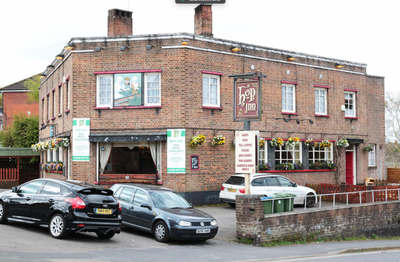


{
    "type": "image",
    "source": {
        "type": "url",
        "url": "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB/observation_0_EtYs8nud5yDzZaZQfEZtUY.png"
    }
}

user: Where was the picture taken?


In [16]:
structured_output = None
await print_test(messages_test_crop[0], _stream_prefix, True)

In [ ]:
msg_reasoning = await reasoning()

In [ ]:
msg_reasoning.get_content_blocks(
            "tool_use",
        )[0]

In [ ]:
print(msg_reasoning)

user: The observation_index of the following image is 0.

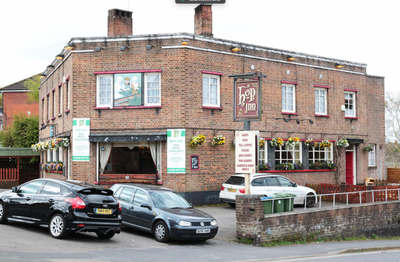


{
    "type": "image",
    "source": {
        "type": "url",
        "url": "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB/observation_0_EtYs8nud5yDzZaZQfEZtUY.png"
    }
}

user: Where was the picture taken?
TestAgent(thinking): To determine where the picture was taken, I need to identify the building and its location. The most prominent clue is the sign hanging on the front of the building. I will zoom in on the sign to read the text and gather more details.

TestAgent: 

{
    "type": "tool_use",
    "id": "call_27c48b8a8aa54284aac81efc",
    "name": "zoom_in_image",
    "input": {
        "label": "the main sign on the building",
        "bbox_2d": [
            574,
            273,
            661,
            467
        ],
        "observation_index": 0
    },
    "raw_input": "{\"label\": \"the main sign on the building\", \"bbox_2d\": [574, 273, 661, 467], \"observation_index\": 0}"
}
[TOOL_CALL] zoom_in_image
system: {
    "type": "tool_result

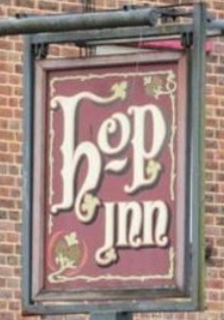

2026-03-24 11:56:24,508 | WARNING | _openai_formatter:_format:338 - Unsupported block type thinking in the message, skipped.



{
    "type": "image",
    "source": {
        "type": "url",
        "url": "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB/observation_1_5RYic55yNwvoxvHzfTqyea.png"
    }
}

user: </system-info>
TestAgent(thinking): The user wants to know where the picture was taken. I have successfully zoomed in on the main sign of the building, which clearly reads "Hop Inn". This is a very strong clue. To find the location, I need to search for this establishment.

My plan is to:
1.  Search for "Hop Inn pub" to find its location.
2.  If that doesn't yield a specific address, I'll look for more clues in the original image, such as phone numbers or other signs. I can see a phone number on the green signs in the original image. I will use that as a secondary method if needed.

Let's start by searching for the name of the pub.

TestAgent: 

Based on the sign in the image, the establishment is called the "Hop Inn". I will now search for this name to determine its location.


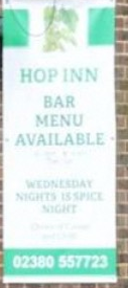

2026-03-24 11:56:27,803 | WARNING | _openai_formatter:_format:338 - Unsupported block type thinking in the message, skipped.
2026-03-24 11:56:27,804 | WARNING | _openai_formatter:_format:338 - Unsupported block type thinking in the message, skipped.



{
    "type": "image",
    "source": {
        "type": "url",
        "url": "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB/observation_2_SPGn6iFKpXoUQts4VBvsjQ.png"
    }
}

user: </system-info>
TestAgent(thinking): The cropped image shows a sign for the "Hop Inn". It also displays a phone number, "02380 557723". The "02380" area code is a key piece of information, as it corresponds to the Southampton area in the United Kingdom. This provides a specific geographic region to search within. I will now use the name "Hop Inn" and the area code "02380" to search for the exact location.

TestAgent: 

{
    "type": "tool_use",
    "id": "call_3a3a2cef8ed54d8ab2378504",
    "name": "zoom_in_image",
    "input": {
        "label": "the license plate of the black car",
        "bbox_2d": [
            233,
            793,
            289,
            822
        ],
        "observation_index": 0
    },
    "raw_input": "{\"label\": \"the license plate of the blac

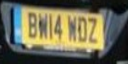

2026-03-24 11:56:30,532 | WARNING | _openai_formatter:_format:338 - Unsupported block type thinking in the message, skipped.
2026-03-24 11:56:30,533 | WARNING | _openai_formatter:_format:338 - Unsupported block type thinking in the message, skipped.
2026-03-24 11:56:30,534 | WARNING | _openai_formatter:_format:338 - Unsupported block type thinking in the message, skipped.



{
    "type": "image",
    "source": {
        "type": "url",
        "url": "/data/home/zhangchen/project/RL/SlideReasoner/result/test_task/TCGA-BH-A0EB/observation_3_ZP7gYGSLarqCLppBNKgepE.png"
    }
}

user: </system-info>
TestAgent(thinking): The user wants to know the location where the picture was taken. I have gathered several pieces of evidence from the image to determine this.

1.  **Establishment Name:** The main hanging sign on the building clearly says "Hop Inn". A green banner on the wall also reads "HOP INN BAR MENU AVAILABLE".
2.  **Phone Number:** The same green banner displays a phone number: `02380 557723`. The `02380` area code is for Southampton, United Kingdom.
3.  **Vehicle License Plate:** The license plate on the black car in the foreground is `BW14 WDZ`. This is a UK registration plate. The '14' indicates the car was registered between March and August 2014. The 'B' prefix typically corresponds to the Birmingham area, but this doesn't mean the car is currently

In [19]:
structured_output = None
await print_test(messages_test_crop[0], _stream_prefix, True)

for _ in range(20):

    msg_reasoning = await reasoning()


    futures = [
        acting(tool_call)
        for tool_call in msg_reasoning.get_content_blocks(
            "tool_use",
        )
    ]

    structured_outputs = [await _ for _ in futures]
    
    if not msg_reasoning.has_content_blocks("tool_use"):
        # Exit the loop when no structured output is required (or
        # already satisfied) and only text response is generated
        msg_reasoning.metadata = structured_output
        reply_msg = msg_reasoning
        break

## Test reasoning

In [17]:
async def reasoning(
        tool_choice: Literal["auto", "none", "required"] | None = None,
) -> Msg:
    """Perform the reasoning process."""
    # Convert Msg objects into the required format of the model API

    prompt = await formatter.format(
        msgs=[
            Msg("system", analysis_prompt, "system"),
            *await memory.get_memory(),

        ],
    )

    res = await model(
        prompt,
        tools=toolkit.get_json_schemas(),
        tool_choice=tool_choice,
    )

    msg = None



    msg = Msg(name=name, content=[], role="assistant")


    if model.stream:
        async for content_chunk in res:
            msg.content = content_chunk.content


            await print_test(msg, _stream_prefix, False)

    else:
        msg.content = list(res.content)

    await print_test(msg, _stream_prefix, True)

    # Add a tiny sleep to yield the last message object in the message queue
    await asyncio.sleep(0.001)



    await memory.add(msg)

    return msg

## Test acting

In [18]:
async def acting(tool_call: ToolUseBlock) -> dict | None:

    """Perform the acting process, and return the structured output if
    it's generated and verified in the finish function call.

    Args:
        tool_call (`ToolUseBlock`):
            The tool use block to be executed.

    Returns:
        `Union[dict, None]`:
            Return the structured output if it's verified in the finish
            function call, otherwise return None.
    """

    tool_res_msg = Msg(
        "system",
        [
            ToolResultBlock(
                type="tool_result",
                id=tool_call["id"],
                name=tool_call["name"],
                output=[],
            ),
        ],
        "system",
    )

    try:
        # Execute the tool call

        print(f"[TOOL_CALL] {tool_call["name"]}")
        
        if tool_call["name"] not in toolkit.tools:
            tool_res_msg.content[0][  # type: ignore[index]
                "output"
            ] = [
                TextBlock(
                    type="text",
                    text=f"FunctionNotFoundError: {tool_call["name"]} is not available. You must not call {tool_call["name"]} again. Available tools: {f'{ [ _ for _ in toolkit.tools.keys() ]}.'}"
                )
                ]
            await print_test(tool_res_msg, _stream_prefix, True)
            return None
            
        tool_res = await toolkit.call_tool_function(tool_call)

        # Async generator handling
        async for chunk in tool_res:
            # Turn into a tool result block
            tool_res_msg.content[0][  # type: ignore[index]
                "output"
            ] = chunk.content

            await print_test(tool_res_msg, _stream_prefix, chunk.is_last)

            # Raise the CancelledError to handle the interruption in the
            # handle_interrupt function
            if chunk.is_interrupted:
                raise asyncio.CancelledError()
            
        return None

    finally:
        # Record the tool result message in the memory

        if tool_call['name'] == "zoom_in_image":

            if chunk.metadata['success']:
                print(f"[TOOL_RESPONSE] {tool_call["name"]}")
                (
                    textual_output,
                    multimodal_data,
                ) = convert_tool_result_to_string(tool_res_msg.content[0]["output"])

                if len(textual_output) != 1:
                    raise ValueError(f"the respone of zoom_in_image must contain only 1 textual_output, but got len(textual_output) = {len(textual_output)}")

                if len(multimodal_data) != 1:
                    raise ValueError(f"the respone of zoom_in_image must contain only 1 multimodal_data, but got len(multimodal_data) = {len(multimodal_data)}")
                textual_output = textual_output[0]
                multimodal_data = multimodal_data[0]
                
                tool_res_msg_text = Msg(
                    "system",
                    [
                        ToolResultBlock(
                            type="tool_result",
                            id=tool_res_msg.content[0]['id'],
                            name=tool_res_msg.content[0]['name'],
                            output=[
                                textual_output[1]
                            ],
                        ),
                    ],
                    "system",
                )

                await print_test(tool_res_msg_text, _stream_prefix, True)

                await memory.add(tool_res_msg_text)

                promoted_blocks_image: list = []

                url, multimodal_block = multimodal_data
                if (
                    multimodal_block["type"] == "image"
                ):
                    promoted_blocks_image.extend(
                        [
                            TextBlock(
                                type="text",
                                text=f"\n- This image is labeled with observation_index {chunk.metadata['observation_index']}, generated by applying the zoom_in_image function to the image with observation_index {chunk.metadata['source_observation_index']}: ",
                            ),
                            ImageBlock(
                                type="image",
                                source=URLSource(
                                    type="url",
                                    url=url,
                                ),
                            ),
                        ],
                    )
                if promoted_blocks_image:
                    # Insert promoted blocks as new user message(s)
                    promoted_blocks_image = [
                        TextBlock(
                            type="text",
                            text="<system-info>The following are "
                            "the image contents from the tool "
                            f"result of '{tool_res_msg.content[0]['name']}':",
                        ),
                        *promoted_blocks_image,
                        TextBlock(
                            type="text",
                            text="</system-info>",
                        ),
                    ]
                    promoted_msg_image = Msg(
                        name="user",
                        content=promoted_blocks_image,
                        role="user",
                    )
                    await print_test(promoted_msg_image, _stream_prefix, True)

                    await memory.add(promoted_msg_image)
        else:
            await memory.add(tool_res_msg)

def convert_tool_result_to_string(
    output: str | List[TextBlock | ImageBlock | AudioBlock | VideoBlock],
) -> tuple[
    str,
    Sequence[
        Tuple[
            str,
            ImageBlock | AudioBlock | TextBlock | VideoBlock,
        ]
    ],
]:
    """Turn the tool result list into a textual output to be compatible
    with the LLM API that doesn't support multimodal data in the tool
    result.

    For URL-based images, the URL is included in the list. For
    base64-encoded images, the local file path where the image is saved
    is included in the returned list.

    Args:
        output (`str | List[TextBlock | ImageBlock | AudioBlock | \
        VideoBlock]`):
            The output of the tool response, including text and multimodal
            data like images and audio.

    Returns:
        `tuple[str, list[Tuple[str, ImageBlock | AudioBlock | VideoBlock \
        TextBlock]]]`:
            A tuple containing the textual representation of the tool
            result and a list of tuples. The first element of each tuple
            is the local file path or URL of the multimodal data, and the
            second element is the corresponding block.
    """

    if isinstance(output, str):
        return output, []

    textual_output = []
    multimodal_data = []
    for block in output:
        assert isinstance(block, dict) and "type" in block, (
            f"Invalid block: {block}, a TextBlock, ImageBlock, "
            f"AudioBlock, or VideoBlock is expected."
        )
        if block["type"] == "text":
            # textual_output.append(block["text"])
            textual_output.append((block["text"], block))

        elif block["type"] in ["image", "audio", "video"]:
            assert "source" in block, (
                f"Invalid {block['type']} block: {block}, 'source' key "
                "is required."
            )
            source = block["source"]
            # Save the image locally and return the file path
            if source["type"] == "url":

                path_multimodal_file = source["url"]

            # elif source["type"] == "base64":
            #     path_multimodal_file = _save_base64_data(
            #         source["media_type"],
            #         source["data"],
            #     )
            #     textual_output.append(
            #         f"The returned {block['type']} can be found "
            #         f"at: {path_multimodal_file}",
            #     )

            else:
                raise ValueError(
                    f"Invalid image source: {block['source']}, "
                    "expected 'url' or 'base64'.",
                )

            multimodal_data.append(
                (path_multimodal_file, block),
            )

        else:
            raise ValueError(
                f"Unsupported block type: {block['type']}, "
                "expected 'text', 'image', 'audio', or 'video'.",
            )

    # if len(textual_output) == 1:
    #     return textual_output[0], multimodal_data

    # else:
    #     return "\n".join("- " + _ for _ in textual_output), multimodal_data

    return textual_output, multimodal_data

In [ ]:
await memory.get_memory()